# Implementation of Activity Cliff Splitting

Activity Cliff Splitting is one of the four suggested biased splitting methods in this project. It is *suggested* merely as an example of what is possible when we think in terms of answering a chemically meaningful question by constructing biased train test split to validate model performance.

**The question we want to answer using activity cliff** is `"How does the model performance change when the increasing fractions of test molecules have at least one training-set neighbour that is structurally similar but has a very different activity?"`

All the questions tend to follow the schema: "How does the model performance change when <increasing/decreasing> fractions of test molecules `<question>`".
We can get that answer with relative ease using the term `Bias`. Bias (bounded [0,1]) here means the fraction of test set that answers True for the given chemically meaningful question. In this case, we are checking for Activity Cliff, thus we define bias as follows:

A pair (a, b) is a cliff edge when:
  - Tanimoto(a, b) >= similarity_threshold, AND
  - |y_a - y_b| >= activity_threshold   (regression) OR y_a != y_b (classification)

Test set construction targets `n_cliff_test_molecules = floor(intended_bias * test_fraction * N)` cliff test molecules by walking cliff edges sorted randomly, assigning higher-degree endpoint to train and the partner to test (heuristic, one can do this in random order as well). Random fill closes the test set to `floor(test_fraction * N)` molecules. Effective bias is measured after the split is fully made and it checks the fraction of test molecules that have at least one cliff edge to a training molecule.

In [1]:
import os
from PIL import Image
import tempfile
import numpy as np
import pandas as pd
import networkx as nx
from biased_split import (smiles_to_ecfp4_bitvect, 
                          compute_similarity_matrix, 
                          df_to_ecfp4_molecular_network,
                          visualise_molnet_split)

Let's first implement the calculator for effective bias in a general sense where we check that question has a result first, then we check that those results are not NaNs and actually True (1) /False (0). We simply report the mean True value as the effective bias which is the fraction of test molecules that have at least one cliff edge to training molecule in this case.

In [2]:
def effective_bias_from_question_results(question_results):
    if question_results.size == 0:
        return 0.0
    eligible = question_results[~np.isnan(question_results)]
    if eligible.size == 0:
        return 0.0
    return float(eligible.mean())

My idea about constructing this split is as follows:

- We construct the molecular network
- all nodes are assigned as `UNASSIGNED_NODE`
- we then find out cliff edges using the conditional as stated above.
- we sort these cliff edges by the difference in activity (largest difference -> smallest difference)
- loop through these cliff edges. Put the highest degree node as `TRAIN_NODE` and lower degree node in `TEST_NODE`.
- if the degrees are same, pick one randomly to `TRAIN_NODE`.
- if for an edge, a node is already classified as `TRAIN_NODE`, the other node is put in `TEST_NODE` and vice versa.
- if both nodes are classified, we skip that edge.
- we repeat this till bias fraction of test set is filled after which we randomly sample, first from non cliff nodes and if they are not present in sufficient numbers, then from cliff nodes to complete test set and compute and report effective bias

In [3]:
UNASSIGNED_NODE = 0
TRAIN_NODE = 1
TEST_NODE = 2

Let's write a helped to find all the cliff edges first so we can easily look them up later on.

In [4]:
def find_cliff_edges(similarity_matrix, activity_values, similarity_threshold, activity_threshold):
    n = len(activity_values)
    cliff_edges = []

    for i in range(n):
        for j in range(i + 1, n): # symmetric matrix
            if similarity_matrix[i, j] < similarity_threshold:
                continue
            activity_difference = abs(float(activity_values[i]) - float(activity_values[j]))
            if activity_difference >= activity_threshold:
                cliff_edges.append((i, j, activity_difference))

    return cliff_edges

We return these edges as a tuple with node idx1, node idx2 and activity difference. 

Now, let's also write a helper for finding out the degree of nodes in these cliffs. Remember here we only care about the cliff nodes's connectivity with other cliff nodes only. Basically the heuristic is that we would be better of putting a molecule in train set if it's highly similar to lots of other molecules (that we can put in test set, thus easily filling up the biased fraction of test set), and has activity difference large enough to make those pairs a cliff.

In [5]:
def compute_cliff_degrees(
    cliff_edges, # these come from before (node idx1, node idx2, activity_difference)
    n_molecules):
    
    degrees = np.zeros(n_molecules, dtype=int)
    for mol_a, mol_b, _ in cliff_edges:
        degrees[mol_a] += 1
        degrees[mol_b] += 1
    return degrees

Let's consolidate the logic of the split now. As I've explained previously, we want to walk these cliff edges and assign them from `UNASSIGNED_NODE` to `TRAIN_NODE` or `TEST_NODE`.

Rules are :
- Both unassigned then higher-degree to train, partner to test.
- Exactly one in train then assign the other to test.
- Exactly one in test then assign the other to train.
- Randomly select if both have same degree.
- Stop once `n_cliff_test_target` molecules have been placed in test by above rules.

We will return the assignment array (values: UNASSIGNED_NODE, TRAIN_NODE, TEST_NODE).

I'm going to write it down explcitly following the zen of python although it'll be much faster and easier to write it in vectorized format. Hopefully this makes it easier to understand and follow the code.

In [6]:
def walk_cliff_edges(cliff_edges, 
                     cliff_degrees, 
                     n_molecules, 
                     n_cliff_test_target, 
                     rng): # this is to ensures reproducibility with random selection
    assignment = np.full(n_molecules, UNASSIGNED_NODE) # array with length of n_molecules filled with 0s
    n_cliff_test_placed = 0

    for mol_a, mol_b, _ in cliff_edges:
        if n_cliff_test_placed >= n_cliff_test_target: # Stop condition as explained above
            break

        status_a = assignment[mol_a]
        status_b = assignment[mol_b]

        if status_a == UNASSIGNED_NODE and status_b == UNASSIGNED_NODE:
            # higher cliff-degree molecule goes to train.
            if cliff_degrees[mol_a] > cliff_degrees[mol_b]:
                train_molecule, test_molecule = mol_a, mol_b
            elif cliff_degrees[mol_b] > cliff_degrees[mol_a]:
                train_molecule, test_molecule = mol_b, mol_a
            else:
                # Equal cliff degree: randomly pick
                if rng.random() < 0.5:
                    train_molecule, test_molecule = mol_a, mol_b
                else:
                    train_molecule, test_molecule = mol_b, mol_a

            assignment[train_molecule] = TRAIN_NODE
            assignment[test_molecule] = TEST_NODE
            n_cliff_test_placed += 1

        elif status_a == TRAIN_NODE and status_b == UNASSIGNED_NODE:
            # Unassigned partner of a train molecule goes to test.
            assignment[mol_b] = TEST_NODE
            n_cliff_test_placed += 1

        elif status_b == TRAIN_NODE and status_a == UNASSIGNED_NODE:
            # Same as above with roles swapped.
            assignment[mol_a] = TEST_NODE
            n_cliff_test_placed += 1

        elif status_a == TEST_NODE and status_b == UNASSIGNED_NODE:
            # Unassigned partner of a test molecule goes to train.
            assignment[mol_b] = TRAIN_NODE

        elif status_b == TEST_NODE and status_a == UNASSIGNED_NODE:
            # Same as above just swapped
            assignment[mol_a] = TRAIN_NODE

        # If both are already assigned, there is nothing to do for this edge.

    return assignment

Now we can focus on actually answering the question at hand, Given the train and test node idxs, activity values with threshold for activity cliff and similarity matrix with threshold for similarity, now we want to know for each of the test molecule, if it has AT LEAST ONE cliff neighbour in the training set. If it does then we return 1.0 otherwise 0.0 for that idx.

In [7]:
def evaluate_cliff_question(test_indices, train_indices, activity_values, activity_threshold,
                             similarity_matrix, similarity_threshold):
    if len(test_indices) == 0:
        return np.array([])

    # similarity[i, j] = similarity between test molecule i and train molecule j
    similarity_test_vs_train = similarity_matrix[test_indices[:, None], train_indices]

    # activity_diff[i, j] = |activity(test i) - activity(train j)|
    activity_diff_test_vs_train = np.abs(
        activity_values[test_indices][:, None] - activity_values[train_indices]
    )

    is_cliff_edge = (
        (similarity_test_vs_train >= similarity_threshold)
        & (activity_diff_test_vs_train >= activity_threshold)
    )

    # A test molecule counts if it has at least one cliff edge to any train molecule.
    test_molecule_has_cliff_partner = is_cliff_edge.any(axis=1)
    return test_molecule_has_cliff_partner.astype(float)

Putting it all together now, we can construct a `ActivityCliffSplitter` class.

In [8]:
class ActivityCliffSplitter:
    def __init__(
        self,
        similarity_threshold,
        activity_threshold,
        test_fraction=0.2,  # of total dataset, default 20% of total dataset should be test set
    ):
        self.similarity_threshold = similarity_threshold
        self.activity_threshold = activity_threshold
        self.test_fraction = test_fraction

    def split_for_intended_bias(
        self,
        smiless,
        activity_values,
        similarity_matrix,
        intended_bias,  # this is the fraction that we _try_ to construct. Depending on dataset and parameters this may not be possible and thus we ALWAYS report and use *effective bias*.
        random_seed,
    ):
        if not (0.0 <= intended_bias <= 1.0):
            raise ValueError(f"intended_bias must be in [0, 1], got {intended_bias}")

        rng = np.random.default_rng(random_seed)
        n_molecules = len(smiless)
        # int(2.1) => 2; int(2.9) => 2; thus int here acts as floor operator
        target_test_size = int(self.test_fraction * n_molecules)
        n_cliff_test_molecules = int(intended_bias * target_test_size)

        cliff_edges = find_cliff_edges(
            similarity_matrix=similarity_matrix,
            activity_values=activity_values,
            similarity_threshold=self.similarity_threshold,
            activity_threshold=self.activity_threshold,
        )  # this gives us (node idx1, node idx2, activity difference)

        # One can sort edges so the largest activity gaps are processed first. But in this case, we will randomly sort it.
        # cliff_edges.sort(key=lambda edge: edge[2], reverse=True) # edge[2] is the activity difference from cliff_edges
        rng.shuffle(cliff_edges)

        # calculate cliff degrees for heuristic sorting into TRAIN_NODE
        cliff_degrees = compute_cliff_degrees(cliff_edges, n_molecules)

        # assign the cliff nodes by walking the cliff edges
        assignment = walk_cliff_edges(
            cliff_edges=cliff_edges,
            cliff_degrees=cliff_degrees,
            n_molecules=n_molecules,
            n_cliff_test_target=n_cliff_test_molecules,
            rng=rng,
        )

        unassigned_indices = np.where(assignment == UNASSIGNED_NODE)[0]
        unassigned_non_cliff_indices = unassigned_indices[
            cliff_degrees[unassigned_indices] == 0
        ]
        unassigned_cliff_indices = unassigned_indices[
            cliff_degrees[unassigned_indices] > 0
        ]

        n_random_fill = target_test_size - int((assignment == TEST_NODE).sum())

        if n_random_fill > 0:
            if len(unassigned_non_cliff_indices) >= n_random_fill:
                random_test_indices = rng.choice(
                    unassigned_non_cliff_indices, size=n_random_fill, replace=False
                )
            else:
                shortfall = n_random_fill - len(unassigned_non_cliff_indices)
                cliff_topup_indices = rng.choice(
                    unassigned_cliff_indices,
                    size=min(shortfall, len(unassigned_cliff_indices)),
                    replace=False,
                )
                random_test_indices = np.concatenate(
                    [unassigned_non_cliff_indices, cliff_topup_indices]
                )
            assignment[random_test_indices] = TEST_NODE

        # now, all unassigned molecules go to training.
        assignment[assignment == UNASSIGNED_NODE] = TRAIN_NODE

        train_indices = np.where(assignment == TRAIN_NODE)[0]
        test_indices = np.where(assignment == TEST_NODE)[0]

        question_results = evaluate_cliff_question(
            test_indices=test_indices,
            train_indices=train_indices,
            similarity_matrix=similarity_matrix,
            activity_values=activity_values,
            similarity_threshold=self.similarity_threshold,
            activity_threshold=self.activity_threshold,
        )

        # calculate the effective bias after random sampling.
        effective_bias = effective_bias_from_question_results(question_results)
        return train_indices, test_indices, effective_bias

    def split(self, smiless, activity_values, intended_biases, n_repeats):
        fps_bitvect = [smiles_to_ecfp4_bitvect(smiles) for smiles in smiless]
        similarity_matrix = compute_similarity_matrix(fps_bitvect)

        for intended_bias in intended_biases:
            for repeat_index in range(n_repeats):
                train_indices, test_indices, effective_bias = (
                    self.split_for_intended_bias(
                        smiless,
                        activity_values,
                        similarity_matrix,
                        intended_bias,
                        repeat_index,
                    )
                )
                yield train_indices, test_indices, effective_bias, intended_bias, repeat_index


Let's see if it works

In [9]:
df = pd.read_csv("../data/standardized/target_CHEMBL1163125-1.IC50.csv")

In [10]:
G = df_to_ecfp4_molecular_network(df, 'standardized_smiles', 'pchembl_value', similarity_threshold=0.7, activity_threshold=1)

In [11]:
activity_cliff_splitter = ActivityCliffSplitter(
            similarity_threshold=0.7,
            activity_threshold=1, # 1 log unit of pIC50
            test_fraction=0.2)

In [13]:
fps_bitvect = [smiles_to_ecfp4_bitvect(smiles) for smiles in df['standardized_smiles']] 
similarity_matrix = compute_similarity_matrix(fps_bitvect=fps_bitvect)

In [14]:
train_idx, test_idx, effective_bias = activity_cliff_splitter.split_for_intended_bias(
                         df['standardized_smiles'].values,
                         df['pchembl_value'].values,
                         similarity_matrix=similarity_matrix,
                         intended_bias=1,
                         random_seed=1)

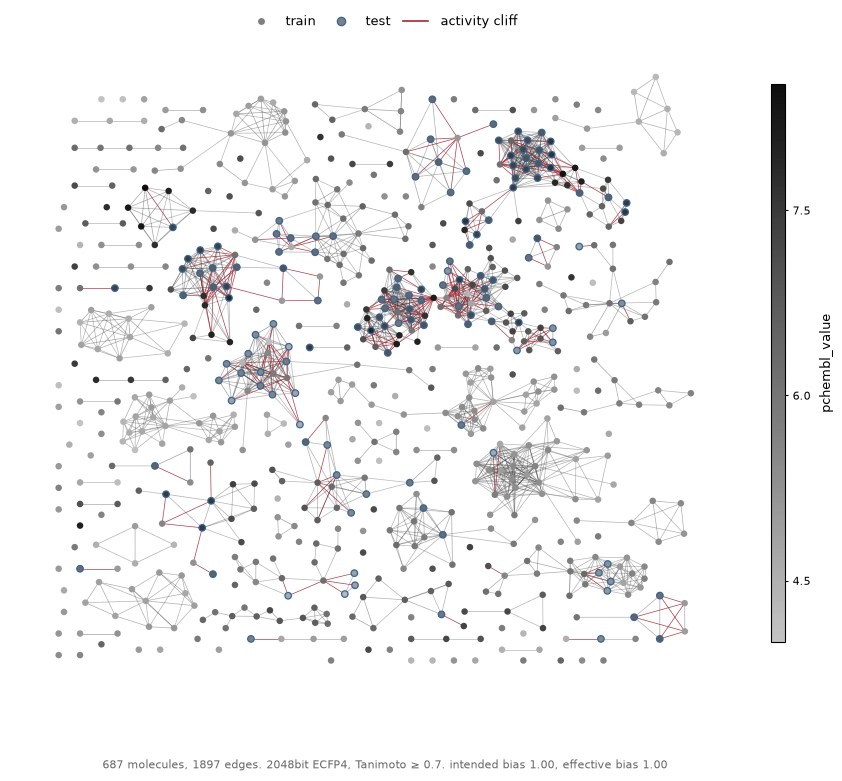

In [15]:
visualise_molnet_split(G, train_idx, test_idx, effective_bias, intended_bias=1)

That looks about right !

let's loop through it and generate a GIF across biases

In [16]:
bias_sweep = activity_cliff_splitter.split(
                                 df['standardized_smiles'].values,
                                 df['pchembl_value'].values,
                                 intended_biases=(np.arange(0,1.1, 0.1)), 
                                 n_repeats=1)

In [17]:
def make_split_gif(G, splitter, output_path, duration=500):
    with tempfile.TemporaryDirectory() as tmpdir:
        paths = []
        for i, (train_idx, test_idx, eff, intended, rep) in enumerate(splitter):
            p = os.path.join(tmpdir, f"frame_{i:04d}.png")
            visualise_molnet_split(G, train_idx, test_idx, eff, intended, filepath=p)
            paths.append(p)
        frames = [Image.open(p) for p in paths]
        frames[0].save(output_path, save_all=True, append_images=frames[1:],
                       duration=duration, loop=0)

In [18]:
make_split_gif(G, bias_sweep, './activity_cliff.gif')

![Molecular Network across Activity Cliff Biases](./activity_cliff.gif)